# Setup

In [1]:
from IPython.display import HTML, IFrame, clear_output, display
import random
import torch
from rich import print as rprint
from rich.table import Table
from tqdm.auto import tqdm
from functools import partial
import torch as t
import torch.nn.functional as F
from torch import Tensor, nn
from jaxtyping import Float, Int
import einops

import matplotlib.pyplot as plt
import numpy as np

device = t.device("mps" if t.backends.mps.is_available() else "cuda" if t.cuda.is_available() else "cpu")

from sae_lens import (
    SAE,
    ActivationsStore,
    HookedSAETransformer,
    LanguageModelSAERunnerConfig,
    SAEConfig,
    SAETrainingRunner,
    upload_saes_to_huggingface,
)

from transformer_lens import ActivationCache, HookedTransformer, utils
from transformer_lens.hook_points import HookPoint
from tabulate import tabulate

In [2]:
# from huggingface_hub import login
# login()

In [3]:
# import inspect
# print(inspect.getfile(gemma_2_2b.__class__))

In [4]:
# gemma-2-2b has layer 0 to layer 25

gemmascope_sae_release = "gemma-scope-2b-pt-mlp-canonical"
# gemmascope_sae_id = "layer_20/width_16k/canonical"
gemmascope_all_sae_ids = [
    f"layer_{i}/width_16k/canonical" for i in range(0,26)
]

In [5]:
gemmascope_all_sae_ids

['layer_0/width_16k/canonical',
 'layer_1/width_16k/canonical',
 'layer_2/width_16k/canonical',
 'layer_3/width_16k/canonical',
 'layer_4/width_16k/canonical',
 'layer_5/width_16k/canonical',
 'layer_6/width_16k/canonical',
 'layer_7/width_16k/canonical',
 'layer_8/width_16k/canonical',
 'layer_9/width_16k/canonical',
 'layer_10/width_16k/canonical',
 'layer_11/width_16k/canonical',
 'layer_12/width_16k/canonical',
 'layer_13/width_16k/canonical',
 'layer_14/width_16k/canonical',
 'layer_15/width_16k/canonical',
 'layer_16/width_16k/canonical',
 'layer_17/width_16k/canonical',
 'layer_18/width_16k/canonical',
 'layer_19/width_16k/canonical',
 'layer_20/width_16k/canonical',
 'layer_21/width_16k/canonical',
 'layer_22/width_16k/canonical',
 'layer_23/width_16k/canonical',
 'layer_24/width_16k/canonical',
 'layer_25/width_16k/canonical']

In [6]:
gemma_2_2b = HookedSAETransformer.from_pretrained("gemma-2-2b", device=device)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded pretrained model gemma-2-2b into HookedTransformer


In [7]:
# gemma_2_2b_sae = SAE.from_pretrained(gemmascope_sae_release, gemmascope_sae_id, device=str(device))[0]
gemma_2_2b_all_sae = [
    SAE.from_pretrained(gemmascope_sae_release, i, device=str(device))[0] for i in gemmascope_all_sae_ids
]

C:\Anaconda\envs\fyp_gemma_testing\Lib\site-packages\sae_lens\saes\sae.py:249: UserWarning: 
This SAE has non-empty model_from_pretrained_kwargs. 
For optimal performance, load the model like so:
model = HookedSAETransformer.from_pretrained_no_processing(..., **cfg.model_from_pretrained_kwargs)
  warnings.warn(
C:\Users\Pey Ruo-Yang\AppData\Local\Temp\ipykernel_16472\3035216223.py:3: DeprecationWarning: Indexing SAE objects is deprecated. SAE.from_pretrained() now returns only the SAE object. Use SAE.from_pretrained_with_cfg_and_sparsity() to get the config dict and sparsity as well.
  SAE.from_pretrained(gemmascope_sae_release, i, device=str(device))[0] for i in gemmascope_all_sae_ids


In [8]:
gemma_2_2b_all_sae[0].cfg

JumpReLUSAEConfig(d_in=2304, d_sae=16384, dtype='float32', device='cuda', apply_b_dec_to_input=False, normalize_activations='none', reshape_activations='none', metadata=SAEMetadata({'sae_lens_version': '6.5.1', 'sae_lens_training_version': None, 'model_name': 'gemma-2-2b', 'hook_name': 'blocks.0.hook_mlp_out', 'hook_head_index': None, 'prepend_bos': True, 'dataset_path': 'monology/pile-uncopyrighted', 'context_size': 1024, 'neuronpedia_id': 'gemma-2-2b/0-gemmascope-mlp-16k'}))

# Test

In [9]:
prompt = "The safety of nuclear energy is often"
answer = " safer"

In [10]:
output_no_steer = gemma_2_2b(prompt)
# Get probabilities
probs = torch.softmax(output_no_steer[0, -1, :], dim=-1)
top_probs, top_indices = torch.topk(probs, k=10)

for i in range(10):
    token = gemma_2_2b.to_string(top_indices[i])
    print(f"{token}: {top_probs[i].item():.2%}")

 questioned: 16.83%
 debated: 8.98%
 a: 7.54%
 discussed: 6.87%
 cited: 6.78%
 the: 3.74%
 called: 3.50%
 compared: 2.81%
 touted: 2.71%
 criticized: 2.40%


In [11]:
prompt = "The safety of nuclear energy is often"
answer = " safer"

In [12]:
utils.test_prompt(prompt, answer, gemma_2_2b)

Tokenized prompt: ['<bos>', 'The', ' safety', ' of', ' nuclear', ' energy', ' is', ' often']
Tokenized answer: [' safer']


Performance on answer token:
Rank: 560      Logit: 15.86 Prob:  0.00% Token: | safer|

Top 0th token. Logit: 25.97 Prob: 16.83% Token: | questioned|
Top 1th token. Logit: 25.34 Prob:  8.98% Token: | debated|
Top 2th token. Logit: 25.16 Prob:  7.54% Token: | a|
Top 3th token. Logit: 25.07 Prob:  6.87% Token: | discussed|
Top 4th token. Logit: 25.06 Prob:  6.78% Token: | cited|
Top 5th token. Logit: 24.46 Prob:  3.74% Token: | the|
Top 6th token. Logit: 24.40 Prob:  3.50% Token: | called|
Top 7th token. Logit: 24.18 Prob:  2.81% Token: | compared|
Top 8th token. Logit: 24.14 Prob:  2.71% Token: | touted|
Top 9th token. Logit: 24.02 Prob:  2.40% Token: | criticized|


Ranks of the answer tokens: [(' safer', 560)]

In [13]:
prompt_2= "The reliability of Wikipedia is very important"

In [14]:
GENERATE_KWARGS = dict(temperature=0.5, freq_penalty=2.0, verbose=False)
gemma_2_2b.generate(prompt_2, max_new_tokens=50, **GENERATE_KWARGS)

"The reliability of Wikipedia is very important for us. It's one of the main sources we use on this site. We have a team that constantly checks for vandalism and errors to make sure our pages are up to date.\n\n<h2>How can I help?</h2>\n\nIf you see"

# SAE

In [15]:
logits, cache = gemma_2_2b.run_with_cache_with_saes(prompt, saes=gemma_2_2b_all_sae)

for name, param in cache.items():
    print(f"{name:<43}: {tuple(param.shape)}")

hook_embed                                 : (1, 8, 2304)
blocks.0.hook_resid_pre                    : (1, 8, 2304)
blocks.0.ln1.hook_scale                    : (1, 8, 1)
blocks.0.ln1.hook_normalized               : (1, 8, 2304)
blocks.0.attn.hook_q                       : (1, 8, 8, 256)
blocks.0.attn.hook_k                       : (1, 8, 4, 256)
blocks.0.attn.hook_v                       : (1, 8, 4, 256)
blocks.0.attn.hook_rot_q                   : (1, 8, 8, 256)
blocks.0.attn.hook_rot_k                   : (1, 8, 4, 256)
blocks.0.attn.hook_attn_scores             : (1, 8, 8, 8)
blocks.0.attn.hook_pattern                 : (1, 8, 8, 8)
blocks.0.attn.hook_z                       : (1, 8, 8, 256)
blocks.0.ln1_post.hook_scale               : (1, 8, 1)
blocks.0.ln1_post.hook_normalized          : (1, 8, 2304)
blocks.0.hook_attn_out                     : (1, 8, 2304)
blocks.0.hook_resid_mid                    : (1, 8, 2304)
blocks.0.ln2.hook_scale                    : (1, 8, 1)
blocks.0.ln

In [16]:
m=cache['blocks.15.hook_mlp_out.hook_sae_input']
# m=cache['blocks.20.attn.hook_z.hook_sae_input']
m.shape

torch.Size([1, 8, 2304])

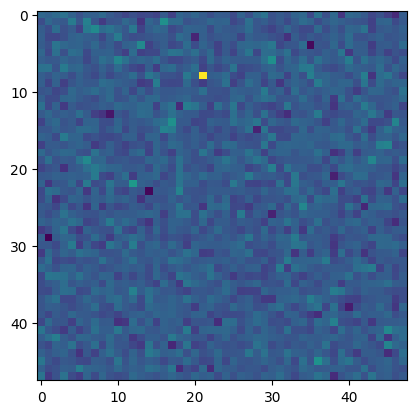

In [17]:
plt.imshow(m[0, -1, :].detach().cpu().numpy().reshape(48,48))

In [18]:
m=cache['blocks.14.ln2_post.hook_normalized']
print(m)

tensor([[[ 0.6372, -0.7531,  0.3857,  ...,  1.1007,  0.2563, -0.8234],
         [ 0.3310,  0.8073, -1.1460,  ..., -0.1277,  0.8967, -0.0654],
         [-0.2343, -0.4049,  0.5045,  ..., -0.3248, -0.4105,  0.2064],
         ...,
         [-1.0496,  0.9071, -0.6116,  ...,  0.3319, -0.4441, -0.2710],
         [-0.4336,  0.2796, -0.6287,  ...,  0.7029,  0.4927, -0.0975],
         [-0.5751,  0.6712, -0.6141,  ...,  0.1590,  1.5253,  0.3172]]],
       device='cuda:0')


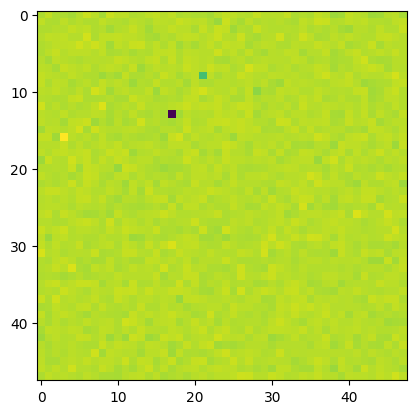

In [19]:
plt.imshow(m[0, -1, :].detach().cpu().numpy().reshape(48,48))

In [20]:
m=cache['blocks.13.hook_mlp_out.hook_sae_acts_post'].detach().cpu().numpy()
# m=cache['blocks.20.attn.hook_z.hook_sae_acts_post']
m.shape

(1, 8, 16384)

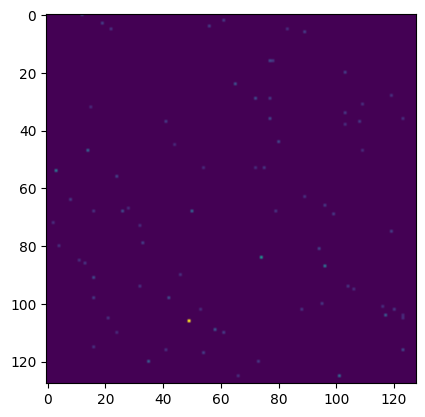

In [21]:
plt.imshow(m[0, -1, :].reshape(128,128))

In [22]:
top_indices = np.argsort(np.abs(m[0,-1]))[-10:][::-1]
m[0,-1][top_indices]

array([17.256948 ,  8.405354 ,  6.4471345,  6.1413364,  5.4316044,
        5.061916 ,  5.0377045,  4.6350236,  4.5723495,  4.2376466],
      dtype=float32)

In [23]:
top_indices

array([13617, 10826,  6915, 11232, 16101,  6030,  8754, 15395, 13429,
       14010], dtype=int64)

# Getting features from all layers

In [24]:
def display_dashboard(
    layer=0,
    latent_idx=0,
    width=1200,
    height=800,
):

    url = f"https://neuronpedia.org/gemma-2-2b/{layer}-gemmascope-mlp-16k/{latent_idx}?embed=true&embedexplanation=true&embedplots=true&embedtest=true&height=300"

    print(url)
    display(IFrame(url, width=width, height=height))

In [25]:
features = []
residual_l = []
for i in range(0, 26):
    plt.figure()
    
    m=cache[f'blocks.{str(i)}.hook_mlp_out.hook_sae_acts_post'].detach().cpu().numpy()
    features.append(m)
    # plt.imshow(m[0, -1, :].reshape(128,128))
    # plt.title(f"Layer {str(i)} features")
    # plt.show()
    # plt.close()

    r=cache[f'blocks.{i}.hook_resid_post'].detach().cpu().numpy() # r shape is (1, seq len, 2304)
    # print(r.shape)
    # residual_l.append(r)
    # plt.imshow(r[0, -1, :].reshape(48,48))
    # plt.title(f"Layer {str(i)} residual stream")
    # plt.show()
    # plt.close()
    
    top_indices = np.argsort(np.abs(m[0,-1]))[-10:][::-1][:5]
    print(f"Layer {str(i)} top feature indices: {top_indices}")
    for ind in top_indices:
        # print(f"Latent {ind} had activation {act:.2f}")
        # display_dashboard(latent_idx=ind)
        display_dashboard(layer=i, latent_idx=ind)

Layer 0 top feature indices: [7337 1024 6047 2104 9640]
https://neuronpedia.org/gemma-2-2b/0-gemmascope-mlp-16k/7337?embed=true&embedexplanation=true&embedplots=true&embedtest=true&height=300


https://neuronpedia.org/gemma-2-2b/0-gemmascope-mlp-16k/1024?embed=true&embedexplanation=true&embedplots=true&embedtest=true&height=300


https://neuronpedia.org/gemma-2-2b/0-gemmascope-mlp-16k/6047?embed=true&embedexplanation=true&embedplots=true&embedtest=true&height=300


https://neuronpedia.org/gemma-2-2b/0-gemmascope-mlp-16k/2104?embed=true&embedexplanation=true&embedplots=true&embedtest=true&height=300


https://neuronpedia.org/gemma-2-2b/0-gemmascope-mlp-16k/9640?embed=true&embedexplanation=true&embedplots=true&embedtest=true&height=300


...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [26]:
r=cache['blocks.25.hook_resid_post']
l = gemma_2_2b.unembed(r)
probs=l[:,-1,:].softmax(dim=-1)
token_probs, token_ids = probs[-1, :].topk(10, dim=-1)

for tk, p in zip(token_ids, token_probs):
    print(gemma_2_2b.to_string(tk.item()))

 a
 the
 considered
 an
 discussed
 one
 associated
 regarded
 taken
 seen


# Idea: zero out certain features and see how it affects the downstream features and final output

In [27]:
activations_from_steering_hook = {}

def steering_hook(
    activations: Float[Tensor, "batch pos d_in"],
    hook: HookPoint,
    sae: SAE,
    latent_idx: int,
    layer_idx: int,
    steering_coefficient: float,
) -> Tensor:
    """
    Steers the model by returning a modified activations tensor, with some multiple of the steering vector added to all
    sequence positions.
    """
    activations_from_steering_hook[layer_idx] = activations[:, :-1, :]
    return activations + steering_coefficient * sae.W_dec[latent_idx] #Hmm wow how can we visualize this - interesting. Pretty simple in a way.


def generate_with_steering( #Ah I could do a version of this for neurons - right!
    model: HookedSAETransformer,
    sae: SAE,
    prompt: str,
    latent_idx: int,
    steering_coefficient: float = 1.0,
    max_new_tokens: int = 50,
):
    """
    Generates text with steering. A multiple of the steering vector (the decoder weight for this latent) is added to
    the last sequence position before every forward pass.
    """
    _steering_hook = partial(
        steering_hook,
        sae=sae,
        latent_idx=latent_idx,
        steering_coefficient=steering_coefficient,
    )

    with model.hooks(fwd_hooks=[(sae.cfg.hook_name, _steering_hook)]):
        output = model.generate(prompt, max_new_tokens=max_new_tokens, **GENERATE_KWARGS)

    return output

In [268]:
gemma_2_2b.reset_hooks()
# latent_idx=12568
latent_idx=5365
# sae_layer=14
sae_layer=6
_steering_hook = partial(
    steering_hook,
    sae=gemma_2_2b_all_sae[sae_layer],
    latent_idx=latent_idx,
    layer_idx=sae_layer,
    steering_coefficient=100,
)
sae_layer_2=15
_steering_hook_2 = partial( # Make another hook with no steering coeff so it hooks the sae activations
    steering_hook,
    sae=gemma_2_2b_all_sae[sae_layer],
    latent_idx=latent_idx,
    layer_idx=sae_layer_2,
    steering_coefficient=0,
)
sae_layer_3=25
_steering_hook_3 = partial( # Make another hook with no steering coeff so it hooks the sae activations
    steering_hook,
    sae=gemma_2_2b_all_sae[sae_layer],
    latent_idx=latent_idx,
    layer_idx=sae_layer_3,
    steering_coefficient=0,
)
sae_layer_4=13
_steering_hook_4 = partial( # Make another hook with no steering coeff so it hooks the sae activations
    steering_hook,
    sae=gemma_2_2b_all_sae[sae_layer],
    latent_idx=latent_idx,
    layer_idx=sae_layer_4,
    steering_coefficient=0,
)

sae_input_hooks = {}

def capture_sae_input(x, hook):
    sae_input_hooks['activation'] = x.detach().clone()
    return x  # forward must return the input

# attach to the SAE's hook_sae_input
gemma_2_2b_all_sae[sae_layer].hook_sae_input.add_perma_hook(capture_sae_input)

# features_after_steering = []
residual_after_steering = {}

def capture_residual_hook(layer_idx):
    def hook_fn(
        activation: Float[Tensor, "batch pos d_model"],
        hook: HookPoint,
    ) -> None:
        """Capture residual stream for specific layer."""
        residual_after_steering[layer_idx] = activation.clone()
    return hook_fn
# Add hooks to capture residuals
residual_hooks_after_steering = []
for layer in range(26):
    residual_hooks_after_steering.append((f"blocks.{layer}.hook_resid_post", capture_residual_hook(layer)))

mlp_out_after_steering = {}

def capture_mlp_out_hook(layer_idx):
    def hook_fn(
        activation: Float[Tensor, "batch pos d_model"],
        hook: HookPoint,
    ) -> None:
        """Capture residual stream for specific layer."""
        mlp_out_after_steering[layer_idx] = activation.clone()
    return hook_fn
# Add hooks to capture residuals
mlp_out_hooks_after_steering = []
for layer in range(26):
    mlp_out_hooks_after_steering.append((f"blocks.{layer}.hook_mlp_out", capture_mlp_out_hook(layer)))

# with gemma_2_2b.hooks(fwd_hooks=[("blocks.20.hook_mlp_out", _steering_hook), *residual_hooks_after_steering]):
#     _, cache = gemma_2_2b.run_with_cache_with_saes(
#         prompt,
#         saes=gemma_2_2b_all_sae,
#         stop_at_layer=25+1,
#     )

In [269]:
# captured = {}

# def extract_sae(layer):
#     def hook_fn(activation, hook):
#         print(f"extracting sae input from layer {layer}")
#         captured[layer] = activation.detach().clone()
#         return activation
#     return hook_fn
# # Add hooks to capture sae
# # sae_hooks_after_steering = []
# # for layer in range(26):
# #     sae_hooks_after_steering.append((f"blocks.{layer}.hook_mlp_out.hook_sae_input", extract_sae(layer)))

# for layer, sae in enumerate(gemma_2_2b_all_sae):
#     sae.add_hook("hook_sae_input", extract_sae(layer))

with gemma_2_2b.hooks(fwd_hooks=[(f"blocks.{sae_layer}.hook_mlp_out", _steering_hook), *residual_hooks_after_steering]):
    utils.test_prompt(
        prompt,
        " safer",
        model=gemma_2_2b,
    )

Tokenized prompt: ['<bos>', 'The', ' safety', ' of', ' nuclear', ' energy', ' is', ' often']
Tokenized answer: [' safer']


Performance on answer token:
Rank: 657      Logit: 16.21 Prob:  0.00% Token: | safer|

Top 0th token. Logit: 24.87 Prob:  9.43% Token: | cited|
Top 1th token. Logit: 24.75 Prob:  8.42% Token: | touted|
Top 2th token. Logit: 24.27 Prob:  5.20% Token: | overlooked|
Top 3th token. Logit: 24.19 Prob:  4.80% Token: | a|
Top 4th token. Logit: 23.96 Prob:  3.83% Token: | the|
Top 5th token. Logit: 23.79 Prob:  3.22% Token: | used|
Top 6th token. Logit: 23.78 Prob:  3.19% Token: | discussed|
Top 7th token. Logit: 23.52 Prob:  2.46% Token: | questioned|
Top 8th token. Logit: 23.48 Prob:  2.35% Token: | debated|
Top 9th token. Logit: 23.33 Prob:  2.03% Token: | emphasized|


Ranks of the answer tokens: [(' safer', 657)]

In [278]:
gemma_2_2b.reset_hooks()
captured = {}

def extract_sae(layer):
    def hook_fn(activation, hook):
        print(f"extracting sae input from layer {layer}")
        captured[layer] = activation.detach().clone()
        return activation
    return hook_fn
# Add hooks to capture sae
# sae_hooks_after_steering = []
# for layer in range(26):
#     sae_hooks_after_steering.append((f"blocks.{layer}.hook_mlp_out.hook_sae_input", extract_sae(layer)))

for layer, sae in enumerate(gemma_2_2b_all_sae):
    sae.reset_hooks()
for layer, sae in enumerate(gemma_2_2b_all_sae):
    sae.add_hook("hook_sae_input", extract_sae(layer))

def sae_steering(latent_idx, layer_idx, steering_coefficient, sae):
    def hook_fn(
        activations: Float[Tensor, "batch pos d_in"],
        hook: HookPoint,
    ) -> Tensor:
        """
        Steers the model by returning a modified activations tensor, with some multiple of the steering vector added to all
        sequence positions.
        """
        print(f"steering at layer {layer_idx}")
        activations[:,:,latent_idx] = activations[:,:,latent_idx] * steering_coefficient
        return activations
    return hook_fn
# gemma_2_2b_all_sae[14].add_hook("hook_sae_acts_post", sae_steering(12568,14,100, gemma_2_2b_all_sae[14]))
# gemma_2_2b_all_sae[6].add_hook("hook_sae_acts_post", sae_steering(5235,6,99, gemma_2_2b_all_sae[6]))


# gemma_2_2b.add_hook("blocks.14.hook_mlp_out", sae_steering(12568,14,200, gemma_2_2b_all_sae[14]))
output = gemma_2_2b.run_with_hooks_with_saes(
    prompt,
    saes=gemma_2_2b_all_sae,
    reset_saes_end=True,
    reset_hooks_end=True
)

extracting sae input from layer 0
extracting sae input from layer 1
extracting sae input from layer 2
extracting sae input from layer 3
extracting sae input from layer 4
extracting sae input from layer 5
extracting sae input from layer 6
steering at layer 6
extracting sae input from layer 7
extracting sae input from layer 8
extracting sae input from layer 9
extracting sae input from layer 10
extracting sae input from layer 11
extracting sae input from layer 12
extracting sae input from layer 13
extracting sae input from layer 14
extracting sae input from layer 15
extracting sae input from layer 16
extracting sae input from layer 17
extracting sae input from layer 18
extracting sae input from layer 19
extracting sae input from layer 20
extracting sae input from layer 21
extracting sae input from layer 22
extracting sae input from layer 23
extracting sae input from layer 24
extracting sae input from layer 25


In [279]:
probs = torch.softmax(output[0, -1, :], dim=-1)
top_probs, top_indices = torch.topk(probs, k=10)

for i in range(10):
    token = gemma_2_2b.to_string(top_indices[i])
    print(f"{token}: {top_probs[i].item():.2%}")

 a: 14.57%
 the: 11.60%
 considered: 6.81%
 an: 5.11%
 discussed: 3.89%
 one: 3.01%
 associated: 2.27%
 regarded: 2.08%
 taken: 1.98%
 seen: 1.95%


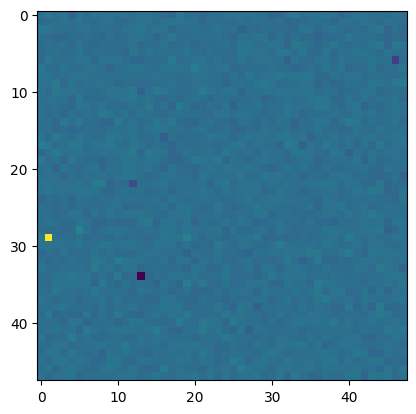

In [280]:
layer=25
m=cache[f'blocks.{layer}.hook_mlp_out.hook_sae_input']
plt.imshow(m[0, -1, :].detach().cpu().numpy().reshape(48,48))

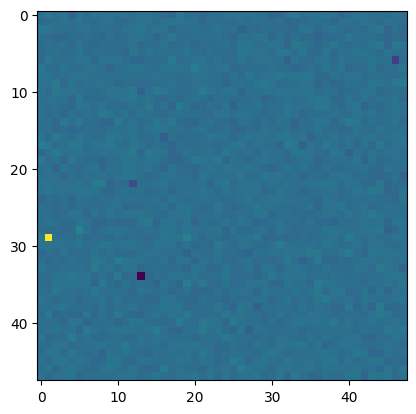

In [276]:
z=captured[layer]
plt.imshow(z[0, -1, :].detach().cpu().numpy().reshape(48,48))

In [277]:
(z[0, -1, :]-m[0, -1, :]).max()

tensor(0., device='cuda:0')

In [31]:
x = mlp_out_after_steering[layer][:,:-1,:]
y = cache[f"blocks.{layer}.hook_mlp_out.hook_sae_input"]

print(x.dtype, y.dtype)
print((x - y).abs().mean())
print(torch.corrcoef(
    torch.stack([x.flatten(), y.flatten()])
)[0, 1])
diff = (x - y).abs()
print(diff.min(), diff.mean(), diff.max())

torch.float32 torch.float32
tensor(3.3740, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.4365, device='cuda:0', grad_fn=<SelectBackward0>)
tensor(0.0003, device='cuda:0', grad_fn=<MinBackward1>) tensor(3.3740, device='cuda:0', grad_fn=<MeanBackward0>) tensor(43.7951, device='cuda:0', grad_fn=<MaxBackward1>)


In [160]:
gemma_2_2b.reset_hooks()
latent_idx=12568    
sae_layer=14
_no_steering_hook = partial(
    steering_hook,
    sae=gemma_2_2b_all_sae[sae_layer],
    latent_idx=latent_idx,
    layer_idx=sae_layer,
    steering_coefficient=0,
)

residual_no_steering = {}

def capture_residual_hook_no_steering(layer_idx):
    def hook_fn(
        activation: Float[Tensor, "batch pos d_model"],
        hook: HookPoint,
    ) -> None:
        """Capture residual stream for specific layer."""
        residual_no_steering[layer_idx] = activation.clone()
    return hook_fn
# Add hooks to capture residuals
residual_hooks_no_steering = []
for layer in range(26):
    residual_hooks_no_steering.append((f"blocks.{layer}.hook_resid_post", capture_residual_hook_no_steering(layer)))

# with gemma_2_2b.hooks(fwd_hooks=[("blocks.20.hook_mlp_out", _no_steering_hook), *residual_hooks_no_steering]):
#     _, cache = gemma_2_2b.run_with_cache_with_saes(
#         prompt,
#         saes=gemma_2_2b_all_sae,
#         stop_at_layer=25+1,
#     )

In [161]:
with gemma_2_2b.hooks(fwd_hooks=[(f"blocks.{sae_layer}.hook_mlp_out", _no_steering_hook), *residual_hooks_no_steering]):
    utils.test_prompt(prompt, "safer", gemma_2_2b)
    l, c = gemma_2_2b.run_with_cache_with_saes(
        prompt,
        saes=gemma_2_2b_all_sae
    )

# Get probabilities
probs = torch.softmax(l[0, -1, :], dim=-1)
top_probs, top_indices = torch.topk(probs, k=10)

for i in range(10):
    token = gemma_2_2b.to_string(top_indices[i])
    print(f"{token}: {top_probs[i].item():.2%}")

Tokenized prompt: ['<bos>', 'The', ' safety', ' of', ' nuclear', ' energy', ' is', ' often']
Tokenized answer: [' safer']


Performance on answer token:
Rank: 560      Logit: 15.86 Prob:  0.00% Token: | safer|

Top 0th token. Logit: 25.97 Prob: 16.83% Token: | questioned|
Top 1th token. Logit: 25.34 Prob:  8.98% Token: | debated|
Top 2th token. Logit: 25.16 Prob:  7.54% Token: | a|
Top 3th token. Logit: 25.07 Prob:  6.87% Token: | discussed|
Top 4th token. Logit: 25.06 Prob:  6.78% Token: | cited|
Top 5th token. Logit: 24.46 Prob:  3.74% Token: | the|
Top 6th token. Logit: 24.40 Prob:  3.50% Token: | called|
Top 7th token. Logit: 24.18 Prob:  2.81% Token: | compared|
Top 8th token. Logit: 24.14 Prob:  2.71% Token: | touted|
Top 9th token. Logit: 24.02 Prob:  2.40% Token: | criticized|


Ranks of the answer tokens: [(' safer', 560)]

runnin'
runnin'
runnin'
runnin'
runnin'
 a: 14.57%
 the: 11.60%
 considered: 6.81%
 an: 5.11%
 discussed: 3.89%
 one: 3.01%
 associated: 2.27%
 regarded: 2.08%
 taken: 1.98%
 seen: 1.95%


In [43]:
from sklearn.decomposition import PCA

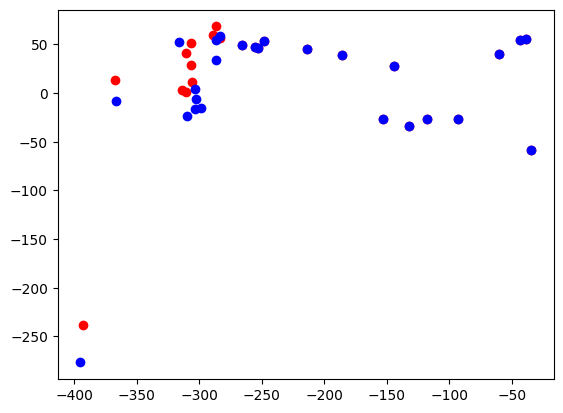

In [44]:
x_after_steering = []
y_after_steering = []
x_before = []
y_before = []
for layer, act in residual_after_steering.items():
    act_pca = PCA(n_components=2, random_state=42).fit_transform(act[0].detach().cpu().numpy())
    x_after_steering.append(act_pca[-1,0])
    y_after_steering.append(act_pca[-1,1])

for layer, act in residual_no_steering.items():
    act_pca = PCA(n_components=2, random_state=42).fit_transform(act[0].detach().cpu().numpy())
    x_before.append(act_pca[-1,0])
    y_before.append(act_pca[-1,1])

plt.figure()
plt.scatter(x_after_steering, y_after_steering, color="r")
plt.scatter(x_before, y_before, color="b")
plt.show()

In [45]:
# 1. take the NEXT-TOKEN position
r_next = residual_no_steering[25][:, -2, :]                      # [batch, d_model]

# 2. apply final layernorm
r_next = gemma_2_2b.ln_final(r_next)

# 3. unembed to vocab
logits = gemma_2_2b.unembed(r_next)       # [batch, vocab]

# 4. convert to probabilities
probs = logits.softmax(dim=-1)

# 5. inspect top tokens
top_probs, top_ids = probs[0].topk(10)
for tk, p in zip(top_ids, top_probs):
    print(gemma_2_2b.to_string(tk.item()), float(p))


 questioned 0.8022507429122925
 debated 0.07725120335817337
 a 0.04227868467569351
 discussed 0.031001562252640724
 cited 0.029763570055365562
 the 0.004574570804834366
 called 0.0037558695767074823
 compared 0.0020006559789180756
 touted 0.0018048032652586699
 criticized 0.0012702494859695435


# Checking SAE features from steered and unsteered model

In [179]:
logits_no_steering, cache_no_steering = gemma_2_2b.run_with_cache_with_saes(prompt, saes=gemma_2_2b_all_sae)

for name, param in cache.items():
    if "hook_sae" in name:
        print(f"{name:<43}: {tuple(param.shape)}")

utils.test_prompt(prompt, "safer", gemma_2_2b)

blocks.0.hook_mlp_out.hook_sae_input       : (1, 8, 2304)
blocks.0.hook_mlp_out.hook_sae_acts_pre    : (1, 8, 16384)
blocks.0.hook_mlp_out.hook_sae_acts_post   : (1, 8, 16384)
blocks.0.hook_mlp_out.hook_sae_recons      : (1, 8, 2304)
blocks.0.hook_mlp_out.hook_sae_output      : (1, 8, 2304)
blocks.1.hook_mlp_out.hook_sae_input       : (1, 8, 2304)
blocks.1.hook_mlp_out.hook_sae_acts_pre    : (1, 8, 16384)
blocks.1.hook_mlp_out.hook_sae_acts_post   : (1, 8, 16384)
blocks.1.hook_mlp_out.hook_sae_recons      : (1, 8, 2304)
blocks.1.hook_mlp_out.hook_sae_output      : (1, 8, 2304)
blocks.2.hook_mlp_out.hook_sae_input       : (1, 8, 2304)
blocks.2.hook_mlp_out.hook_sae_acts_pre    : (1, 8, 16384)
blocks.2.hook_mlp_out.hook_sae_acts_post   : (1, 8, 16384)
blocks.2.hook_mlp_out.hook_sae_recons      : (1, 8, 2304)
blocks.2.hook_mlp_out.hook_sae_output      : (1, 8, 2304)
blocks.3.hook_mlp_out.hook_sae_input       : (1, 8, 2304)
blocks.3.hook_mlp_out.hook_sae_acts_pre    : (1, 8, 16384)
blocks.

Performance on answer token:
Rank: 560      Logit: 15.86 Prob:  0.00% Token: | safer|

Top 0th token. Logit: 25.97 Prob: 16.83% Token: | questioned|
Top 1th token. Logit: 25.34 Prob:  8.98% Token: | debated|
Top 2th token. Logit: 25.16 Prob:  7.54% Token: | a|
Top 3th token. Logit: 25.07 Prob:  6.87% Token: | discussed|
Top 4th token. Logit: 25.06 Prob:  6.78% Token: | cited|
Top 5th token. Logit: 24.46 Prob:  3.74% Token: | the|
Top 6th token. Logit: 24.40 Prob:  3.50% Token: | called|
Top 7th token. Logit: 24.18 Prob:  2.81% Token: | compared|
Top 8th token. Logit: 24.14 Prob:  2.71% Token: | touted|
Top 9th token. Logit: 24.02 Prob:  2.40% Token: | criticized|


Ranks of the answer tokens: [(' safer', 560)]

In [188]:
# Use the same steering hook above where there is a noticable change in output token distribution
gemma_2_2b.reset_hooks()
latent_idx=12568
sae_layer=14
_steering_hook = partial(
    steering_hook,
    sae=gemma_2_2b_all_sae[sae_layer],
    latent_idx=latent_idx,
    steering_coefficient=100,
)

# features_after_steering = []
residual_after_steering = {}

def capture_residual_hook(layer_idx):
    def hook_fn(
        activation: Float[Tensor, "batch pos d_model"],
        hook: HookPoint,
    ) -> None:
        """Capture residual stream for specific layer."""
        residual_after_steering[layer_idx] = activation.clone()
    return hook_fn
# Add hooks to capture residuals
residual_hooks_after_steering = []
for layer in range(26):
    residual_hooks_after_steering.append((f"blocks.{layer}.hook_resid_post", capture_residual_hook(layer)))

with gemma_2_2b.hooks(fwd_hooks=[(f"blocks.{sae_layer}.hook_mlp_out", _steering_hook), *residual_hooks_after_steering]):
    utils.test_prompt(prompt, "safer", gemma_2_2b)
    # logits_after_steering, cache_after_steering = gemma_2_2b.run_with_cache_with_saes(prompt, saes=gemma_2_2b_all_sae)

    for name, param in cache.items():
        if "hook_sae" in name:
            print(f"{name:<43}: {tuple(param.shape)}")


Tokenized prompt: ['<bos>', 'The', ' safety', ' of', ' nuclear', ' energy', ' is', ' often']
Tokenized answer: [' safer']


Performance on answer token:
Rank: 660      Logit: 16.44 Prob:  0.00% Token: | safer|

Top 0th token. Logit: 25.73 Prob:  7.49% Token: | questioned|
Top 1th token. Logit: 25.33 Prob:  5.06% Token: | a|
Top 2th token. Logit: 25.17 Prob:  4.30% Token: | cited|
Top 3th token. Logit: 25.13 Prob:  4.12% Token: | touted|
Top 4th token. Logit: 25.00 Prob:  3.61% Token: | used|
Top 5th token. Logit: 24.94 Prob:  3.41% Token: | portrayed|
Top 6th token. Logit: 24.93 Prob:  3.39% Token: | overlooked|
Top 7th token. Logit: 24.78 Prob:  2.91% Token: | misunderstood|
Top 8th token. Logit: 24.65 Prob:  2.56% Token: | the|
Top 9th token. Logit: 24.65 Prob:  2.54% Token: | criticized|


Ranks of the answer tokens: [(' safer', 660)]

blocks.0.hook_mlp_out.hook_sae_input       : (1, 8, 2304)
blocks.0.hook_mlp_out.hook_sae_acts_pre    : (1, 8, 16384)
blocks.0.hook_mlp_out.hook_sae_acts_post   : (1, 8, 16384)
blocks.0.hook_mlp_out.hook_sae_recons      : (1, 8, 2304)
blocks.0.hook_mlp_out.hook_sae_output      : (1, 8, 2304)
blocks.1.hook_mlp_out.hook_sae_input       : (1, 8, 2304)
blocks.1.hook_mlp_out.hook_sae_acts_pre    : (1, 8, 16384)
blocks.1.hook_mlp_out.hook_sae_acts_post   : (1, 8, 16384)
blocks.1.hook_mlp_out.hook_sae_recons      : (1, 8, 2304)
blocks.1.hook_mlp_out.hook_sae_output      : (1, 8, 2304)
blocks.2.hook_mlp_out.hook_sae_input       : (1, 8, 2304)
blocks.2.hook_mlp_out.hook_sae_acts_pre    : (1, 8, 16384)
blocks.2.hook_mlp_out.hook_sae_acts_post   : (1, 8, 16384)
blocks.2.hook_mlp_out.hook_sae_recons      : (1, 8, 2304)
blocks.2.hook_mlp_out.hook_sae_output      : (1, 8, 2304)
blocks.3.hook_mlp_out.hook_sae_input       : (1, 8, 2304)
blocks.3.hook_mlp_out.hook_sae_acts_pre    : (1, 8, 16384)
blocks.

[[[-0.18927574  0.          0.         ...  0.          2.9454346
    0.        ]
  [ 0.          7.116108    0.         ...  1.932992    0.
    2.2009935 ]
  [-1.8450994   4.8821545   0.         ...  0.          0.
    6.187765  ]
  ...
  [ 0.          0.          0.         ...  0.          0.
    0.        ]
  [ 0.          0.          0.         ...  0.          0.
    0.        ]
  [ 0.20548248  0.          0.         ...  0.          0.
    0.        ]]]


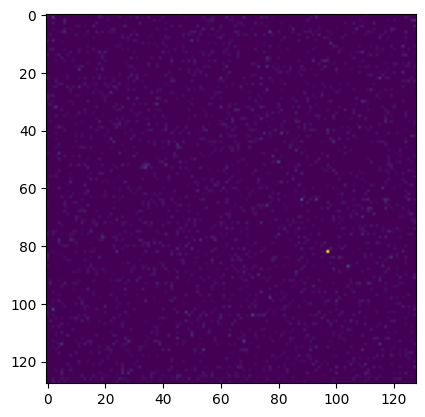

In [237]:
layer = 25
z_1 = gemma_2_2b_all_sae[layer].encode(residual_no_steering[layer][:,:-1,:]).detach().cpu().numpy()
z_2 = gemma_2_2b_all_sae[layer].encode(residual_after_steering[layer][:,:-1,:]).detach().cpu().numpy()
plt.imshow(z_2[0, -1, :].reshape(128,128))
print(z_2-z_1)